# Customer Complaint Resolution System

## Phase 1: Model Bulding

In [2]:
import kagglehub
path = kagglehub.dataset_download("namigabbasov/consumer-complaint-dataset")

100%|██████████| 669M/669M [00:18<00:00, 38.7MB/s]

Extracting files...


In [3]:
file_path = f"{path}/complaints.csv"

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv(file_path)

In [6]:
df.head()

,Unnamed: 0,product_5,narrative,Product,Date received,Sub-product,Issue,Sub-issue,Company,State,Timely response?
0,234,Credit Reporting,Dear Possible Financial Inc you guyss aree rep...,Credit reporting or other personal consumer re...,2024-07-27,Credit reporting,Incorrect information on your report,Account information incorrect,Possible Financial Inc,MI,Yes
1,240,Debt Collection,"XXXX XXXX XXXX ( debt collector ), sent my boy...",Debt collection,2024-07-27,I do not know,Threatened to contact someone or share informa...,Talked to a third-party about your debt,BlueChip Financial,TX,Yes
2,257,Credit Reporting,I been receiving alerts my information was fou...,Credit reporting or other personal consumer re...,2024-07-23,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,FC HoldCo LLC,SC,Yes
3,271,Credit Reporting,Subject : Dispute of Inaccurate Information on...,Credit reporting or other personal consumer re...,2024-07-27,Credit reporting,Improper use of your report,Reporting company used your report improperly,CORELOGIC INC,GA,Yes
4,276,Loans,They allowed me to use the account for about a...,"Payday loan, title loan, personal loan, or adv...",2024-07-26,Payday loan,Received a loan you didn't apply for,NaN,MoneyLion Inc.,PA,Yes


In [7]:
print(df.shape)

(2023066, 11)


In [8]:
print(df.columns)

Index(['Unnamed: 0', 'product_5', 'narrative', 'Product', 'Date received',
       'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State',
       'Timely response?'],
      dtype='object')


##### Check Missing Values

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

Sub-issue           230559
Sub-product          52206
State                 7344
narrative                0
product_5                0
Unnamed: 0               0
Product                  0
Issue                    0
Date received            0
Company                  0
Timely response?         0
dtype: int64


In [10]:
print(df["Issue"].value_counts().head(20))

Issue
Incorrect information on your report                                                524954
Improper use of your report                                                         296875
Problem with a credit reporting company's investigation into an existing problem    250399
Attempts to collect debt not owed                                                   107254
Problem with a company's investigation into an existing problem                      95214
Managing an account                                                                  55637
Written notification about debt                                                      48998
Trouble during payment process                                                       41975
Problem with a purchase shown on your statement                                      32813
False statements or representation                                                   25718
Communication tactics                                                               

#### Data Preparation

In [11]:
# Keep only required columns.
df = df[
    [
        "narrative",
        "Issue"

    ]
]
print(df.shape)

(2023066, 2)


In [12]:
df.head()

,narrative,Issue
0,Dear Possible Financial Inc you guyss aree rep...,Incorrect information on your report
1,"XXXX XXXX XXXX ( debt collector ), sent my boy...",Threatened to contact someone or share informa...
2,I been receiving alerts my information was fou...,Improper use of your report
3,Subject : Dispute of Inaccurate Information on...,Improper use of your report
4,They allowed me to use the account for about a...,Received a loan you didn't apply for


In [13]:
df.isnull().sum()

,0
narrative,0
Issue,0


#### Reduce Classes

In [14]:
# Keep Top 15 Issues.
top_issues = df["Issue"].value_counts().head(10).index

df = df[df["Issue"].isin(top_issues)]

print(df.shape)

(1479837, 2)


In [15]:
min_count = df['Issue'].value_counts().min()

df = (
    df.groupby('Issue')
      .sample(
          n=min_count,
          random_state=42
      )
      .reset_index(drop=True)
)

In [16]:
df['Issue'].value_counts()

,count
Issue,
Attempts to collect debt not owed,25718
False statements or representation,25718
Improper use of your report,25718
Incorrect information on your report,25718
Managing an account,25718
Problem with a company's investigation into an existing problem,25718
Problem with a credit reporting company's investigation into an existing problem,25718
Problem with a purchase shown on your statement,25718
Trouble during payment process,25718


#### Sample 30000 Records

In [17]:
df = df.sample(
    n=30000,
    random_state=42
)
print(df.shape)

(30000, 2)


In [18]:
# Save Original Text
df['original_text'] = df['narrative']

#### Text Length Analysis

In [19]:
df["text_length"] = df["narrative"].apply(
    lambda x: len(str(x).split())
)

df["text_length"].describe()

,text_length
count,30000.000000
mean,201.626867
std,259.511949
min,1.000000
25%,68.000000
50%,129.000000
75%,238.000000
max,5783.000000


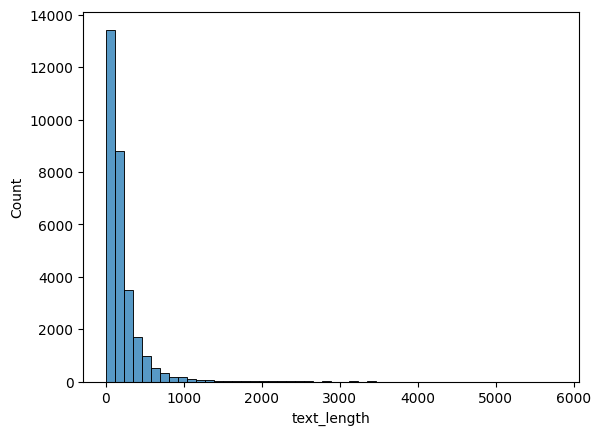

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    df["text_length"],
    bins=50
)

plt.show()

#### NLP Text Cleaning

In [21]:
import nltk
import re
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [22]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z0-9 ]", " ", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [23]:
# Apply
df["clean_text"] = df["narrative"].apply(
    clean_text
)

#### Remove Very Small Complaints

In [24]:
df = df[
    df['clean_text']
      .str.split()
      .str.len() > 10
]

print(df.shape)

(29142, 5)


#### Label Encoding

In [25]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["target"] = encoder.fit_transform(
    df["Issue"]
)
num_classes = encoder.classes_
print(len(num_classes))

10


In [26]:
len(num_classes)

10

#### Train Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["target"],
    test_size=0.2,
    random_state=42,
    stratify=df["target"]
)

In [28]:
df['clean_text'].str.split().str.len().describe()

,clean_text
count,29142.000000
mean,112.945508
std,144.499359
min,11.000000
25%,40.000000
50%,73.000000
75%,134.000000
max,3034.000000


#### Tokenization

In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 15000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [30]:
# Convert Text
train_seq = tokenizer.texts_to_sequences(
    X_train
)

test_seq = tokenizer.texts_to_sequences(
    X_test
)

#### Padding

In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 150

X_train_pad = pad_sequences(
    train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

#### Build BiLSTM Model

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

model = Sequential([

    Embedding(
        VOCAB_SIZE,
        128,
        input_length=MAX_LEN
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        )
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=True
        )
    ),

    GlobalMaxPool1D(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        len(num_classes),
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


#### Compile Model

In [33]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Callbacks

In [34]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

#### Train Model

In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    i:w for i,w in enumerate(weights)
}

In [36]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    class_weight=class_weights
)

Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.2225 - loss: 1.9636 - val_accuracy: 0.3328 - val_loss: 1.6188 - learning_rate: 0.0010
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.3974 - loss: 1.4814 - val_accuracy: 0.4588 - val_loss: 1.3195 - learning_rate: 0.0010
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.4921 - loss: 1.2536 - val_accuracy: 0.5347 - val_loss: 1.2020 - learning_rate: 0.0010
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.5834 - loss: 1.1065 - val_accuracy: 0.5819 - val_loss: 1.1494 - learning_rate: 0.0010
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.6346 - loss: 0.9876 - val_accuracy: 0.6038 - val_loss: 1.1405 - learning_rate: 0.0010
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6779 - loss: 0.9033 - val_accuracy: 0.5918 - val_loss: 1.1506 - learning_rate: 0.0010
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.7054 - loss: 0.

#### Evaluate

In [37]:
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Accuracy:", accuracy)

183/183 ━━━━━━━━━━━━━━━━━━━━ 41s 222ms/step - accuracy: 0.6022 - loss: 1.1460
Accuracy: 0.6021615862846375


#### Classification Report

In [38]:
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test_pad)

y_pred = np.argmax(
    y_pred,
    axis=1
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

183/183 ━━━━━━━━━━━━━━━━━━━━ 42s 226ms/step
              precision    recall  f1-score   support

           0       0.30      0.35      0.32       568
           1       0.45      0.58      0.51       601
           2       0.70      0.71      0.71       561
           3       0.40      0.41      0.41       550
           4       0.81      0.89      0.85       587
           5       0.62      0.56      0.59       583
           6       0.47      0.30      0.37       582
           7       0.84      0.79      0.81       605
           8       0.88      0.93      0.90       616
           9       0.52      0.45      0.48       576

    accuracy                           0.60      5829
   macro avg       0.60      0.60      0.60      5829
weighted avg       0.60      0.60      0.60      5829



#### ROC-AUC Score

In [39]:
y_prob = model.predict(X_test_pad)

183/183 ━━━━━━━━━━━━━━━━━━━━ 44s 241ms/step


In [40]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr"
)

print(roc_auc)

0.9163202804583126


#### Save Model

In [41]:
model.save(
    "complaint_classifier.h5"
)

In [42]:
# Save Tokenizer
import pickle

with open(
    "tokenizer.pkl",
    "wb"
) as f:

    pickle.dump(
        tokenizer,
        f
    )

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Phase 2: RAG System

#### Create Project Folders

In [47]:
import os

os.makedirs("project/policies", exist_ok=True)

os.makedirs("project/vectorstore", exist_ok=True)

os.makedirs("project/models", exist_ok=True)

In [48]:
# Check
!ls project

models	policies  vectorstore


#### Create Policy Documents

In [49]:
attempts_to_collect_debt_not_owed = """
Debt Collection Policy

Customers have the right to dispute debts they do not owe.

Debt collectors must provide verification of the debt upon request.

Collection activities must stop until debt verification is completed.

Customers may submit supporting documentation to challenge the debt.

Resolution timeline is typically 30 days.
"""

In [50]:
with open(
    "project/policies/attempts_to_collect_debt_not_owed.txt",
    "w"
) as f:

    f.write(attempts_to_collect_debt_not_owed)

In [51]:
false_statements_or_representation = """
False Statements and Representation Policy

Financial institutions must provide accurate information regarding accounts, loans, and services.

Customers may report misleading statements or misrepresentations.

Investigations will review account records, communications, and disclosures.

Corrective actions will be taken if inaccurate information is identified.

Resolution is generally completed within 15 business days.
"""

In [52]:
with open(
    "project/policies/false_statements_or_representation.txt",
    "w"
) as f:

    f.write(false_statements_or_representation)

In [53]:
improper_use_of_your_report = """
Credit Report Usage Policy

Customer credit reports may only be accessed for authorized purposes.

Unauthorized access or misuse of credit reports must be reported immediately.

Investigations include access log reviews and verification procedures.

Customers may receive written findings upon investigation completion.

Resolution typically occurs within 30 days.
"""

In [54]:
with open(
    "project/policies/improper_use_of_your_report.txt",
    "w"
) as f:

    f.write(improper_use_of_your_report)

In [55]:
incorrect_information_on_your_report = """
Credit Report Accuracy Policy

Customers have the right to dispute incorrect information appearing on their credit reports.

Supporting documentation may be requested.

The reporting agency will verify disputed information with data providers.

Verified inaccuracies will be corrected or removed.

Resolution is generally completed within 30 days.
"""

In [56]:
with open(
    "project/policies/incorrect_information_on_your_report.txt",
    "w"
) as f:

    f.write(incorrect_information_on_your_report)

In [57]:
managing_an_account = '''
Account Management Policy

Customers may request assistance regarding account settings, account access, balances, and account maintenance.

Requests are reviewed by customer support representatives.

Account updates require identity verification.

Changes are processed according to company procedures.

Resolution usually occurs within 5 business days.'''

In [58]:
with open(
    "project/policies/managing_an_account.txt",
    "w"
) as f:

    f.write(managing_an_account)

In [59]:
company_investigation_existing_problem = '''
Company Investigation Policy

Customers may request a review of an unresolved issue.

The company will examine previous complaints, account records, and supporting evidence.

Investigation findings will be documented and communicated to the customer.

Additional actions may be taken if errors are identified.

Resolution generally occurs within 15 business days.'''

In [60]:
with open(
    "project/policies/company_investigation_existing_problem.txt",
    "w"
) as f:

    f.write(company_investigation_existing_problem)

In [61]:
credit_reporting_investigation_existing_problem = '''
Credit Reporting Investigation Policy

Customers may dispute the outcome of a previous credit reporting investigation.

Credit reporting agencies will review supporting documentation and account information.

Relevant data providers may be contacted for verification.

Updates will be communicated in writing.

Resolution typically occurs within 30 days.'''

In [62]:
with open(
    "project/policies/credit_reporting_investigation_existing_problem.txt",
    "w"
) as f:

    f.write(credit_reporting_investigation_existing_problem)

In [63]:
purchase_shown_on_statement = '''
Purchase Dispute Policy

Customers may dispute purchases appearing on account statements.

Duplicate transactions, unauthorized purchases, and billing errors are eligible for review.

Transaction details and merchant information may be required.

Temporary credits may be issued during investigation.

Resolution generally occurs within 10 business days.'''

In [64]:
with open(
    "project/policies/purchase_shown_on_statement.txt",
    "w"
) as f:

    f.write(purchase_shown_on_statement)

In [65]:
trouble_during_payment_process = '''
Payment Processing Policy

Customers experiencing payment failures, delays, duplicate payments, or processing errors may submit complaints.

Payment records will be reviewed.

Technical issues will be investigated by payment operations teams.

Corrections will be applied when appropriate.

Resolution generally occurs within 5 business days.'''

In [66]:
with open(
    "project/policies/trouble_during_payment_process.txt",
    "w"
) as f:

    f.write(trouble_during_payment_process)

In [67]:
written_notification_about_debt = '''
Debt Notification Policy

Customers have the right to receive written notification regarding debts.

Debt notices must include creditor information, debt amount, and dispute procedures.

Customers may request verification of debt information.

Collection activities must follow regulatory requirements.

Resolution generally occurs within 30 days.'''

In [68]:
with open(
    "project/policies/written_notification_about_debt.txt",
    "w"
) as f:

    f.write(written_notification_about_debt)

In [69]:
import os

os.listdir(
    "project/policies"
)

['managing_an_account.txt',
 'company_investigation_existing_problem.txt',
 'false_statements_or_representation.txt',
 'credit_reporting_investigation_existing_problem.txt',
 'trouble_during_payment_process.txt',
 'attempts_to_collect_debt_not_owed.txt',
 'improper_use_of_your_report.txt',
 'purchase_shown_on_statement.txt',
 'incorrect_information_on_your_report.txt',
 'written_notification_about_debt.txt']

#### Install RAG Libraries

In [70]:
!pip install -q langchain
!pip install -q langchain-community
!pip install -q sentence-transformers
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 49.3 MB/s eta 0:00:00


#### Load Documents

In [71]:
from langchain_community.document_loaders import TextLoader

import os

documents = []

folder_path = "project/policies"

for file in os.listdir(folder_path):

    loader = TextLoader(
        os.path.join(folder_path,file)
    )

    documents.extend(
        loader.load()
    )

print(len(documents))

/tmp/ipykernel_3195/1409862374.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


10


#### Split Documents

In [72]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)

docs = splitter.split_documents(
    documents
)

print(len(docs))

20


#### Create Embeddings

In [73]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

/tmp/ipykernel_3195/384917042.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#### Create FAISS Vector Database

In [74]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(
    docs,
    embedding_model
)

In [75]:
# Save
vectorstore.save_local(
    "project/vectorstore"
)

#### Test Retrieval

In [76]:
query = "duplicate transaction"

results = vectorstore.similarity_search(
    query,
    k=3
)

for doc in results:

    print(doc.page_content)

    print("="*50)

Purchase Dispute Policy

Customers may dispute purchases appearing on account statements.

Duplicate transactions, unauthorized purchases, and billing errors are eligible for review.

Transaction details and merchant information may be required.
Payment Processing Policy

Customers experiencing payment failures, delays, duplicate payments, or processing errors may submit complaints.

Payment records will be reviewed.

Technical issues will be investigated by payment operations teams.

Corrections will be applied when appropriate.
Additional actions may be taken if errors are identified.

Resolution generally occurs within 15 business days.


## Phase 3: Model + RAG Integration

#### Save Everything

In [77]:
import pickle

model.save(
    "project/models/complaint_classifier.h5"
)

with open(
    "project/models/tokenizer.pkl",
    "wb"
) as f:
    pickle.dump(tokenizer,f)

with open(
    "project/models/label_encoder.pkl",
    "wb"
) as f:
    pickle.dump(encoder,f)

#### Prediction Function

In [78]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_issue(text):

    cleaned = clean_text(text)

    seq = tokenizer.texts_to_sequences(
        [cleaned]
    )

    padded = pad_sequences(
        seq,
        maxlen=MAX_LEN
    )

    pred = model.predict(
        padded,
        verbose=0
    )

    class_id = np.argmax(pred)

    issue = encoder.inverse_transform(
        [class_id]
    )[0]

    confidence = float(np.max(pred))

    return issue, confidence

#### Test Model

In [79]:
complaint = """
My credit card was charged twice.
"""

issue, confidence = predict_issue(
    complaint
)

print(issue)
print(confidence)

Attempts to collect debt not owed
0.3611448109149933


#### Connect FAISS

In [80]:
def retrieve_policy(issue):

    docs = vectorstore.similarity_search(
        issue,
        k=3
    )

    return docs

#### Test Retrieval

In [81]:
docs = retrieve_policy(issue)

for doc in docs:

    print(doc.page_content)

    print("="*50)

Debt Collection Policy

Customers have the right to dispute debts they do not owe.

Debt collectors must provide verification of the debt upon request.

Collection activities must stop until debt verification is completed.

Customers may submit supporting documentation to challenge the debt.
Debt Notification Policy

Customers have the right to receive written notification regarding debts.

Debt notices must include creditor information, debt amount, and dispute procedures.

Customers may request verification of debt information.
Payment Processing Policy

Customers experiencing payment failures, delays, duplicate payments, or processing errors may submit complaints.

Payment records will be reviewed.

Technical issues will be investigated by payment operations teams.

Corrections will be applied when appropriate.


#### Full Pipeline Test

In [82]:
complaint = """
My card was charged twice and I need refund.
"""

issue, confidence = predict_issue(
    complaint
)

print("Issue:",issue)

print("Confidence:",confidence)

docs = retrieve_policy(issue)

for doc in docs:

    print(doc.page_content)

    print("="*50)

Issue: False statements or representation
Confidence: 0.4703943729400635
False Statements and Representation Policy

Financial institutions must provide accurate information regarding accounts, loans, and services.

Customers may report misleading statements or misrepresentations.

Investigations will review account records, communications, and disclosures.
Credit Report Accuracy Policy

Customers have the right to dispute incorrect information appearing on their credit reports.

Supporting documentation may be requested.

The reporting agency will verify disputed information with data providers.

Verified inaccuracies will be corrected or removed.
Credit Reporting Investigation Policy

Customers may dispute the outcome of a previous credit reporting investigation.

Credit reporting agencies will review supporting documentation and account information.

Relevant data providers may be contacted for verification.


## Phase 4: LLM Integration (Gemini)

#### Install Library

In [83]:
!pip install -q google-generativeai

#### Configure Gemini

In [88]:
import google.generativeai as genai

for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

In [89]:
from google.colab import userdata

In [90]:
import google.generativeai as genai

genai.configure(
    api_key=userdata.get("gemini_API_key")
)

model_llm = genai.GenerativeModel(
    "gemini-2.5-flash"
)

#### Create Resolution Generator

In [91]:
def generate_resolution(
    complaint,
    issue,
    retrieved_docs
):

    context = "\n".join(
        [doc.page_content
         for doc in retrieved_docs]
    )

    prompt = f"""
You are a professional customer support agent.

Customer Complaint:
{complaint}

Predicted Issue:
{issue}

Relevant Policies:
{context}

Generate:

1. Complaint Category
2. Issue Summary
3. Relevant Policy
4. Recommended Resolution
5. Expected Resolution Timeline

Keep the response professional.
"""

    response = model_llm.generate_content(
        prompt
    )

    return response.text

#### Test LLM

In [92]:
complaint = """
My credit card was charged twice
and I need a refund.
"""

issue, confidence = predict_issue(
    complaint
)

docs = retrieve_policy(
    issue
)

answer = generate_resolution(
    complaint,
    issue,
    docs
)

print(answer)

Here is the breakdown of the complaint:

**1. Complaint Category:**
Billing Dispute / Transaction Error (potential False Statement or Misrepresentation)

**2. Issue Summary:**
The customer reports that their credit card was charged twice for a single transaction and is requesting a refund for the duplicate charge.

**3. Relevant Policy:**
**False Statements and Representation Policy**
*   This policy applies because if the financial institution's records or subsequent statements reflect two valid charges for a single transaction, it would constitute inaccurate information regarding the account. The institution must provide accurate information, and an uncorrected double charge would misrepresent the true financial obligation or transaction history. An investigation into the double charge is necessary to ensure that all information provided to the customer, including account statements, is accurate and not misleading.

**4. Recommended Resolution:**
1.  Initiate an immediate investigati

#### Create Master Function(This is what Streamlit will call late)

In [93]:
def complaint_assistant(
    complaint
):

    issue, confidence = predict_issue(
        complaint
    )

    docs = retrieve_policy(
        issue
    )

    resolution = generate_resolution(
        complaint,
        issue,
        docs
    )

    return {
        "issue": issue,
        "confidence": confidence,
        "resolution": resolution
    }

#### Final Test

In [94]:
result = complaint_assistant(
    """
    I was charged twice
    for the same purchase.
    """
)

print(result["issue"])

print(result["confidence"])

print(result["resolution"])

Attempts to collect debt not owed
0.3588983118534088
Here is the breakdown of the customer's complaint:

1.  **Complaint Category:** Payment Processing Error (Duplicate Charge)
2.  **Issue Summary:** The customer reports being charged twice for a single purchase, indicating a duplicate payment transaction.
3.  **Relevant Policy:** Payment Processing Policy
4.  **Recommended Resolution:**
    *   Review payment records immediately to verify the duplicate charge.
    *   Initiate an investigation with the payment operations team to identify the cause of the processing error.
    *   Upon confirmation of the duplicate charge, process a full refund for the erroneous transaction to the customer's original payment method.
    *   Communicate the findings and resolution steps to the customer.
5.  **Expected Resolution Timeline:** 3-5 business days for investigation and refund processing to be initiated. The refund may take additional time to reflect on the customer's statement, depending on t